# EDA — `silver_agri_consolidado`

Análisis exploratorio de `data/silver_agri_consolidado.csv` en tres niveles de agregación, más dispersión y correlación:

1. **Por municipio** (todos los cultivos)
2. **Por cultivo** (todos los municipios)
3. **Por municipio × cultivo** (todas las combinaciones con dato)
4. **Dispersión** (std, CV, IQR, sesgo)
5. **Correlación** (Pearson y Spearman)

Variables principales: `hectareas_sembradas`, `hectareas_cosechadas`, `indice_oni`. `precio` y `semestre` se revisan por calidad (suelen venir nulos en este extracto).


In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (12, 5)
plt.rcParams["axes.titlesize"] = 12
plt.rcParams["axes.labelsize"] = 10

DATA_PATH = Path("data/silver_agri_consolidado.csv")
if not DATA_PATH.exists():
    DATA_PATH = Path("../data/silver_agri_consolidado.csv")

df = pd.read_csv(DATA_PATH)
df["ratio_cos_sem"] = np.where(
    df["hectareas_sembradas"] > 0,
    df["hectareas_cosechadas"] / df["hectareas_sembradas"],
    np.nan,
)

print(f"Archivo: {DATA_PATH.resolve()}")
print(f"Shape: {df.shape}")
df.head()


Archivo: /home/jjvallej/work/enigma/pyimport/data/silver_agri_consolidado.csv
Shape: (500, 11)


,tipo_cultivo,anio,semestre,municipio,codigo_cultivo,nombre_cultivo,hectareas_sembradas,hectareas_cosechadas,precio,indice_oni,ratio_cos_sem
0,permanente,2001,NaN,buga,102115,anturios,2.0,1.0,NaN,-0.300,0.500000
1,permanente,2001,NaN,dagua,102115,anturios,3.0,3.0,NaN,-0.300,1.000000
2,permanente,2001,NaN,la cumbre,102115,anturios,7.0,6.0,NaN,-0.300,0.857143
3,permanente,2001,NaN,versalles,102115,anturios,0.4,0.2,NaN,-0.300,0.500000
4,permanente,2000,NaN,el aguila,102117,astromelias,0.9,0.9,NaN,-0.825,1.000000


## 0. Panorama y calidad de datos


In [2]:
overview = {
    "n_filas": len(df),
    "n_municipios": df["municipio"].nunique(),
    "n_cultivos": df["nombre_cultivo"].nunique(),
    "anio_min": int(df["anio"].min()),
    "anio_max": int(df["anio"].max()),
    "ha_sem_total": float(df["hectareas_sembradas"].sum()),
    "ha_cos_total": float(df["hectareas_cosechadas"].sum()),
    "ratio_global": float(df["hectareas_cosechadas"].sum() / df["hectareas_sembradas"].sum()),
}

display(pd.Series(overview, name="valor"))
print("\nNulos (%):")
display((df.isna().mean() * 100).round(1).to_frame("% nulos"))
print("\nTipo de cultivo:")
display(df["tipo_cultivo"].value_counts())
print("\nMunicipios:", sorted(df["municipio"].unique()))
print("\nCultivos:", sorted(df["nombre_cultivo"].unique()))
df.describe(include="all")


n_filas          500.000000
n_municipios      40.000000
n_cultivos         8.000000
anio_min        2000.000000
anio_max        2024.000000
ha_sem_total    8170.030000
ha_cos_total    7923.040000
ratio_global       0.969769
Name: valor, dtype: float64


Nulos (%):


,% nulos
tipo_cultivo,0.0
anio,0.0
semestre,100.0
municipio,0.0
codigo_cultivo,0.0
nombre_cultivo,0.0
hectareas_sembradas,0.0
hectareas_cosechadas,0.0
precio,100.0
indice_oni,0.0



Tipo de cultivo:


tipo_cultivo
permanente     491
transitorio      9
Name: count, dtype: int64


Municipios: ['alcala', 'andalucia', 'argelia', 'bolivar', 'buga', 'bugalagrande', 'caicedonia', 'cali', 'calima darien', 'candelaria', 'dagua', 'el aguila', 'el cairo', 'el cerrito', 'el dovio', 'florida', 'ginebra', 'guacari', 'guadalajara de buga', 'jamundi', 'la cumbre', 'la union', 'la victoria', 'obando', 'palmira', 'pradera', 'restrepo', 'riofrio', 'roldanillo', 'san pedro', 'santiago de cali', 'sevilla', 'toro', 'trujillo', 'tulua', 'versalles', 'vijes', 'yotoco', 'yumbo', 'zarzal']

Cultivos: ['aji', 'anturios', 'astromelias', 'cebolla bulbo', 'cebolla larga', 'flores y follajes', 'heliconias', 'plantas aromaticas']


,tipo_cultivo,anio,semestre,municipio,codigo_cultivo,nombre_cultivo,hectareas_sembradas,hectareas_cosechadas,precio,indice_oni,ratio_cos_sem
count,500,500.000000,0.0,500,5.000000e+02,500,500.000000,500.000000,0.0,500.000000,500.000000
unique,2,NaN,NaN,40,NaN,8,NaN,NaN,NaN,NaN,NaN
top,permanente,NaN,NaN,yumbo,NaN,aji,NaN,NaN,NaN,NaN,NaN
freq,491,NaN,NaN,35,NaN,329,NaN,NaN,NaN,NaN,NaN
mean,NaN,2010.912000,NaN,NaN,9.366802e+05,NaN,16.340060,15.846080,NaN,0.052680,0.958259
std,NaN,7.538562,NaN,NaN,3.226700e+05,NaN,31.957725,31.943985,NaN,0.573929,0.124850
min,NaN,2000.000000,NaN,NaN,1.021400e+04,NaN,0.200000,0.000000,NaN,-0.858000,0.000000
25%,NaN,2004.000000,NaN,NaN,1.050300e+06,NaN,3.000000,3.000000,NaN,-0.300000,1.000000
50%,NaN,2010.000000,NaN,NaN,1.050300e+06,NaN,7.600000,7.000000,NaN,0.058000,1.000000
75%,NaN,2018.000000,NaN,NaN,1.050300e+06,NaN,16.350000,16.000000,NaN,0.458000,1.000000


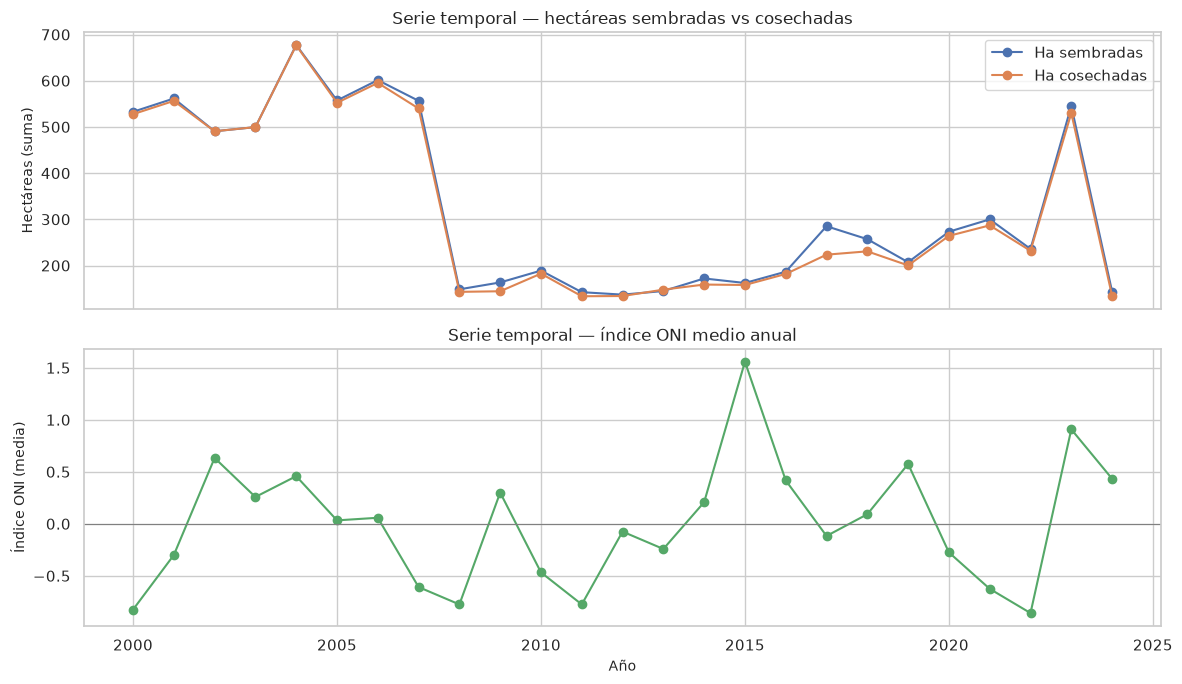

,anio,ha_sem,ha_cos,oni,n
0,2000,532.70,527.60,-0.825,25
1,2001,561.50,556.30,-0.300,31
2,2002,490.60,490.60,0.633,27
3,2003,499.60,499.60,0.258,27
4,2004,677.50,676.50,0.458,32
5,2005,557.20,552.20,0.033,28
6,2006,601.30,595.30,0.058,25
7,2007,556.50,539.90,-0.608,20
8,2008,148.50,143.00,-0.775,13
9,2009,163.40,144.30,0.300,13


In [3]:
by_year = (
    df.groupby("anio", as_index=False)
    .agg(
        ha_sem=("hectareas_sembradas", "sum"),
        ha_cos=("hectareas_cosechadas", "sum"),
        oni=("indice_oni", "mean"),
        n=("anio", "count"),
    )
)

fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True)
axes[0].plot(by_year["anio"], by_year["ha_sem"], marker="o", label="Ha sembradas")
axes[0].plot(by_year["anio"], by_year["ha_cos"], marker="o", label="Ha cosechadas")
axes[0].set_ylabel("Hectáreas (suma)")
axes[0].set_title("Serie temporal — hectáreas sembradas vs cosechadas")
axes[0].legend()

axes[1].plot(by_year["anio"], by_year["oni"], marker="o", color="C2")
axes[1].axhline(0, color="gray", lw=0.8)
axes[1].set_ylabel("Índice ONI (media)")
axes[1].set_xlabel("Año")
axes[1].set_title("Serie temporal — índice ONI medio anual")
plt.tight_layout()
plt.show()
by_year


## 1. Consolidado por municipio (todos los cultivos)

Agregación de todas las filas por `municipio`: cobertura temporal, número de cultivos, suma/media de hectáreas y ratio cosecha/siembra.


In [4]:
by_mun = (
    df.groupby("municipio", as_index=False)
    .agg(
        n_filas=("anio", "count"),
        anio_min=("anio", "min"),
        anio_max=("anio", "max"),
        n_anios=("anio", "nunique"),
        n_cultivos=("nombre_cultivo", "nunique"),
        ha_sem_sum=("hectareas_sembradas", "sum"),
        ha_sem_mean=("hectareas_sembradas", "mean"),
        ha_sem_median=("hectareas_sembradas", "median"),
        ha_sem_std=("hectareas_sembradas", "std"),
        ha_cos_sum=("hectareas_cosechadas", "sum"),
        ha_cos_mean=("hectareas_cosechadas", "mean"),
        oni_mean=("indice_oni", "mean"),
    )
)
by_mun["ratio_cos_sem"] = by_mun["ha_cos_sum"] / by_mun["ha_sem_sum"].replace(0, np.nan)
by_mun["pct_ha_total"] = 100 * by_mun["ha_sem_sum"] / by_mun["ha_sem_sum"].sum()
by_mun = by_mun.sort_values("ha_sem_sum", ascending=False).reset_index(drop=True)

print(f"Municipios: {len(by_mun)} (todos)")
by_mun.round(3)


Municipios: 40 (todos)


,municipio,n_filas,anio_min,anio_max,n_anios,n_cultivos,ha_sem_sum,ha_sem_mean,ha_sem_median,ha_sem_std,ha_cos_sum,ha_cos_mean,oni_mean,ratio_cos_sem,pct_ha_total
0,el cerrito,12,2000,2023,9,3,1953.60,162.800,143.000,103.717,1953.60,162.800,-0.004,1.000,23.912
1,roldanillo,30,2000,2023,24,2,829.28,27.643,26.485,18.257,827.08,27.569,-0.006,0.997,10.150
2,yumbo,35,2000,2024,24,5,786.37,22.468,10.800,30.954,768.33,21.952,0.057,0.977,9.625
3,la union,15,2004,2023,15,1,590.23,39.349,22.900,30.520,575.70,38.380,0.085,0.975,7.224
4,vijes,23,2000,2023,23,1,514.20,22.357,22.000,7.050,514.20,22.357,0.014,1.000,6.294
5,palmira,24,2000,2024,18,4,505.45,21.060,14.315,25.146,503.43,20.976,0.087,0.996,6.187
6,buga,23,2000,2023,13,5,407.90,17.735,11.000,16.745,397.90,17.300,0.105,0.975,4.993
7,dagua,29,2000,2024,24,4,276.30,9.528,9.000,4.686,250.30,8.631,-0.039,0.906,3.382
8,bolivar,21,2001,2023,21,1,253.50,12.071,10.500,9.209,235.50,11.214,-0.024,0.929,3.103
9,toro,14,2000,2022,14,2,222.20,15.871,20.000,7.774,217.20,15.514,0.036,0.977,2.720


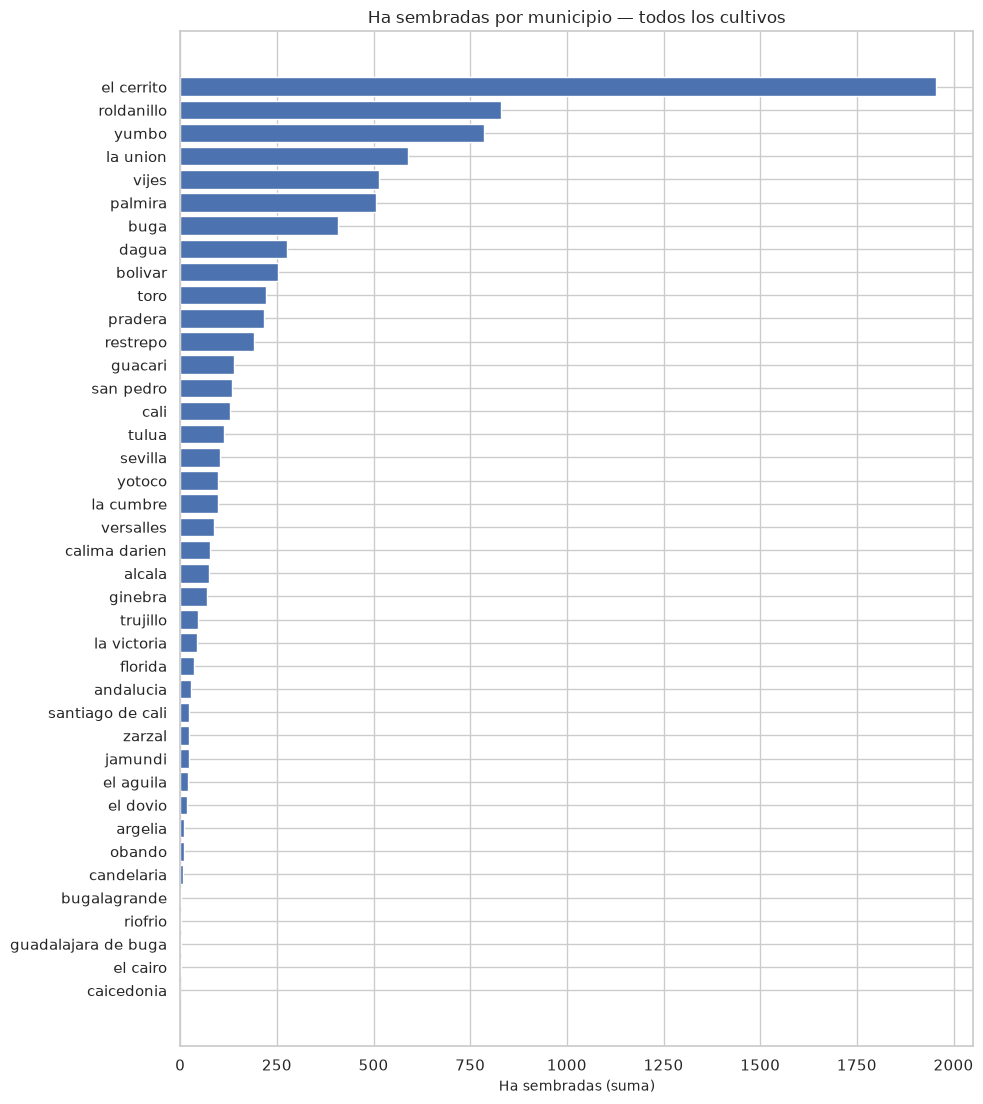

In [5]:
fig, ax = plt.subplots(figsize=(10, max(6, len(by_mun) * 0.28)))
plot_mun = by_mun.sort_values("ha_sem_sum")
ax.barh(plot_mun["municipio"], plot_mun["ha_sem_sum"], color="C0")
ax.set_xlabel("Ha sembradas (suma)")
ax.set_title("Ha sembradas por municipio — todos los cultivos")
plt.tight_layout()
plt.show()


## 2. Consolidado por cultivo (todos los municipios)


In [6]:
by_cul = (
    df.groupby(["nombre_cultivo", "codigo_cultivo", "tipo_cultivo"], as_index=False)
    .agg(
        n_filas=("anio", "count"),
        anio_min=("anio", "min"),
        anio_max=("anio", "max"),
        n_anios=("anio", "nunique"),
        n_municipios=("municipio", "nunique"),
        ha_sem_sum=("hectareas_sembradas", "sum"),
        ha_sem_mean=("hectareas_sembradas", "mean"),
        ha_sem_median=("hectareas_sembradas", "median"),
        ha_sem_std=("hectareas_sembradas", "std"),
        ha_cos_sum=("hectareas_cosechadas", "sum"),
        ha_cos_mean=("hectareas_cosechadas", "mean"),
        oni_mean=("indice_oni", "mean"),
    )
)
by_cul["ratio_cos_sem"] = by_cul["ha_cos_sum"] / by_cul["ha_sem_sum"].replace(0, np.nan)
by_cul["pct_ha_total"] = 100 * by_cul["ha_sem_sum"] / by_cul["ha_sem_sum"].sum()
by_cul = by_cul.sort_values("ha_sem_sum", ascending=False).reset_index(drop=True)

print(f"Cultivos: {len(by_cul)} (todos)")
by_cul.round(3)


Cultivos: 8 (todos)


,nombre_cultivo,codigo_cultivo,tipo_cultivo,n_filas,anio_min,anio_max,n_anios,n_municipios,ha_sem_sum,ha_sem_mean,ha_sem_median,ha_sem_std,ha_cos_sum,ha_cos_mean,oni_mean,ratio_cos_sem,pct_ha_total
0,aji,1050300,permanente,329,2000,2023,24,33,4940.88,15.018,10.0,17.981,4786.41,14.548,-0.011,0.969,60.476
1,cebolla larga,1051200,permanente,98,2000,2007,8,20,2582.30,26.350,6.1,59.773,2572.20,26.247,-0.003,0.996,31.607
2,cebolla bulbo,1051100,transitorio,9,2023,2023,1,9,250.15,27.794,6.4,64.886,240.15,26.683,0.908,0.960,3.062
3,flores y follajes,10214,permanente,49,2014,2019,6,12,229.72,4.688,3.0,7.232,169.00,3.449,0.427,0.736,2.812
4,plantas aromaticas,1022300,permanente,9,2024,2024,1,9,143.68,15.964,14.5,14.121,134.18,14.909,0.433,0.934,1.759
5,anturios,102115,permanente,4,2001,2001,1,4,12.40,3.100,2.5,2.812,10.20,2.550,-0.300,0.823,0.152
6,heliconias,102146,permanente,1,2000,2000,1,1,10.00,10.000,10.0,NaN,10.00,10.000,-0.825,1.000,0.122
7,astromelias,102117,permanente,1,2000,2000,1,1,0.90,0.900,0.9,NaN,0.90,0.900,-0.825,1.000,0.011


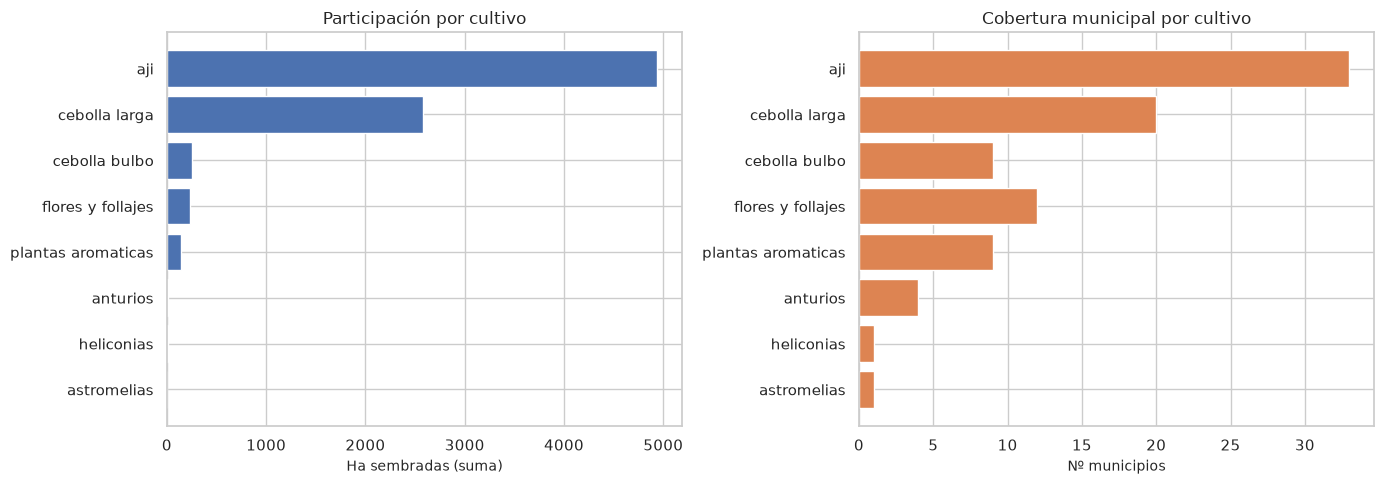

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
plot_cul = by_cul.sort_values("ha_sem_sum")
axes[0].barh(plot_cul["nombre_cultivo"], plot_cul["ha_sem_sum"], color="C0")
axes[0].set_xlabel("Ha sembradas (suma)")
axes[0].set_title("Participación por cultivo")

axes[1].barh(plot_cul["nombre_cultivo"], plot_cul["n_municipios"], color="C1")
axes[1].set_xlabel("Nº municipios")
axes[1].set_title("Cobertura municipal por cultivo")
plt.tight_layout()
plt.show()


## 3. Por municipio × cultivo (todas las combinaciones)

Densidad de la matriz municipio×cultivo y tabla completa de pares con al menos una fila.


Pares con dato: 89 / 320 posibles (27.8%)


,n_cultivos,cultivos
municipio,,
buga,5,"aji, anturios, cebolla bulbo, cebolla larga, f..."
yumbo,5,"aji, cebolla bulbo, cebolla larga, flores y fo..."
versalles,4,"aji, anturios, cebolla larga, flores y follajes"
cali,4,"aji, cebolla bulbo, cebolla larga, flores y fo..."
dagua,4,"aji, anturios, cebolla larga, plantas aromaticas"
la cumbre,4,"aji, anturios, flores y follajes, plantas arom..."
el aguila,4,"astromelias, cebolla bulbo, cebolla larga, hel..."
sevilla,4,"aji, cebolla bulbo, flores y follajes, plantas..."
palmira,4,"aji, cebolla larga, flores y follajes, plantas..."


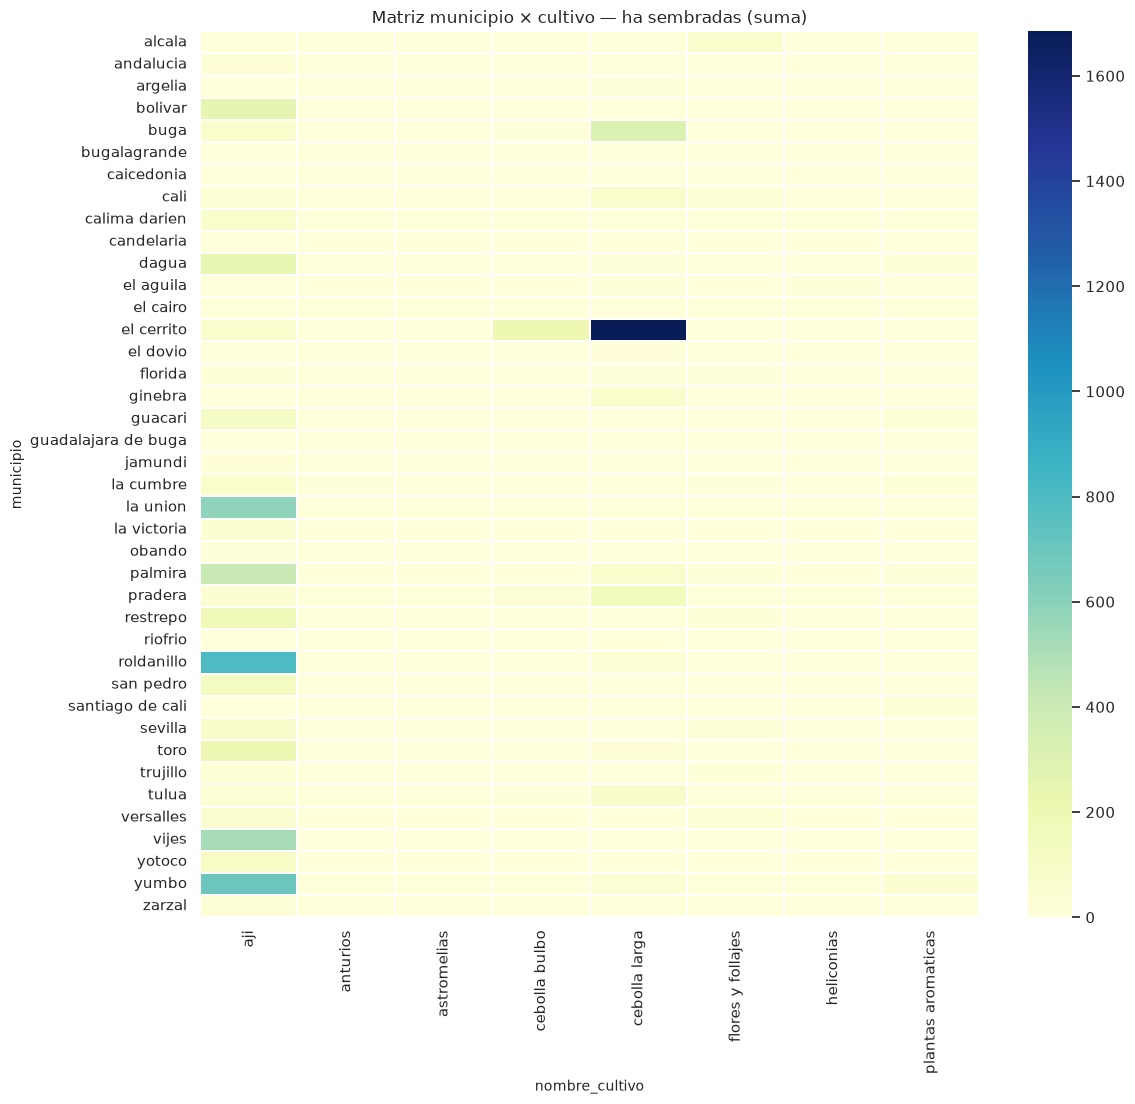

,municipio,nombre_cultivo,codigo_cultivo,tipo_cultivo,n_filas,anio_min,anio_max,n_anios,ha_sem_sum,ha_sem_mean,ha_sem_median,ha_cos_sum,ha_cos_mean,oni_mean,ratio_cos_sem
0,alcala,flores y follajes,10214,permanente,3,2017,2019,3,73.6,24.533,11.20,22.4,7.467,0.183,0.304
1,andalucia,aji,1050300,permanente,6,2000,2009,6,20.8,3.467,3.05,20.3,3.383,0.143,0.976
2,andalucia,flores y follajes,10214,permanente,2,2014,2015,2,6.0,3.000,3.00,6.0,3.000,0.883,1.000
3,argelia,cebolla larga,1051200,permanente,1,2000,2000,1,9.5,9.500,9.50,9.5,9.500,-0.825,1.000
4,argelia,aji,1050300,permanente,1,2023,2023,1,1.0,1.000,1.00,1.0,1.000,0.908,1.000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
84,yumbo,plantas aromaticas,1022300,permanente,1,2024,2024,1,45.8,45.800,45.80,42.8,42.800,0.433,0.934
85,yumbo,cebolla larga,1051200,permanente,7,2000,2006,7,34.3,4.900,3.80,34.3,4.900,0.045,1.000
86,yumbo,cebolla bulbo,1051100,transitorio,1,2023,2023,1,6.4,6.400,6.40,6.4,6.400,0.908,1.000
87,yumbo,flores y follajes,10214,permanente,3,2017,2019,3,3.3,1.100,1.10,3.1,1.033,0.183,0.939


In [8]:
by_mc = (
    df.groupby(["municipio", "nombre_cultivo", "codigo_cultivo", "tipo_cultivo"], as_index=False)
    .agg(
        n_filas=("anio", "count"),
        anio_min=("anio", "min"),
        anio_max=("anio", "max"),
        n_anios=("anio", "nunique"),
        ha_sem_sum=("hectareas_sembradas", "sum"),
        ha_sem_mean=("hectareas_sembradas", "mean"),
        ha_sem_median=("hectareas_sembradas", "median"),
        ha_cos_sum=("hectareas_cosechadas", "sum"),
        ha_cos_mean=("hectareas_cosechadas", "mean"),
        oni_mean=("indice_oni", "mean"),
    )
)
by_mc["ratio_cos_sem"] = by_mc["ha_cos_sum"] / by_mc["ha_sem_sum"].replace(0, np.nan)
by_mc = by_mc.sort_values(["municipio", "ha_sem_sum"], ascending=[True, False]).reset_index(drop=True)

n_pos = len(by_mc)
n_posibles = df["municipio"].nunique() * df["nombre_cultivo"].nunique()
print(f"Pares con dato: {n_pos} / {n_posibles} posibles ({100 * n_pos / n_posibles:.1f}%)")

cultivos_por_mun = (
    by_mc.groupby("municipio")
    .agg(
        n_cultivos=("nombre_cultivo", "nunique"),
        cultivos=("nombre_cultivo", lambda s: ", ".join(sorted(s))),
    )
    .sort_values("n_cultivos", ascending=False)
)
display(cultivos_por_mun)

piv = df.pivot_table(
    index="municipio",
    columns="nombre_cultivo",
    values="hectareas_sembradas",
    aggfunc="sum",
    fill_value=0,
)
fig, ax = plt.subplots(figsize=(12, max(8, len(piv) * 0.28)))
sns.heatmap(piv, cmap="YlGnBu", ax=ax, linewidths=0.2)
ax.set_title("Matriz municipio × cultivo — ha sembradas (suma)")
plt.tight_layout()
plt.show()

by_mc.round(3)


## 4. Análisis de dispersión

Media, desviación estándar, CV (`std/media`), cuartiles, IQR y sesgo — global, por municipio, por cultivo y por municipio×cultivo.


Dispersión global


,n,mean,std,cv,min,p25,median,p75,iqr,max,skew
hectareas_sembradas,500.0,16.340,31.958,1.956,0.200,3.0,7.600,16.350,13.350,300.000,5.708
hectareas_cosechadas,500.0,15.846,31.944,2.016,0.000,3.0,7.000,16.000,13.000,300.000,5.757
indice_oni,500.0,0.053,0.574,10.895,-0.858,-0.3,0.058,0.458,0.758,1.558,0.375


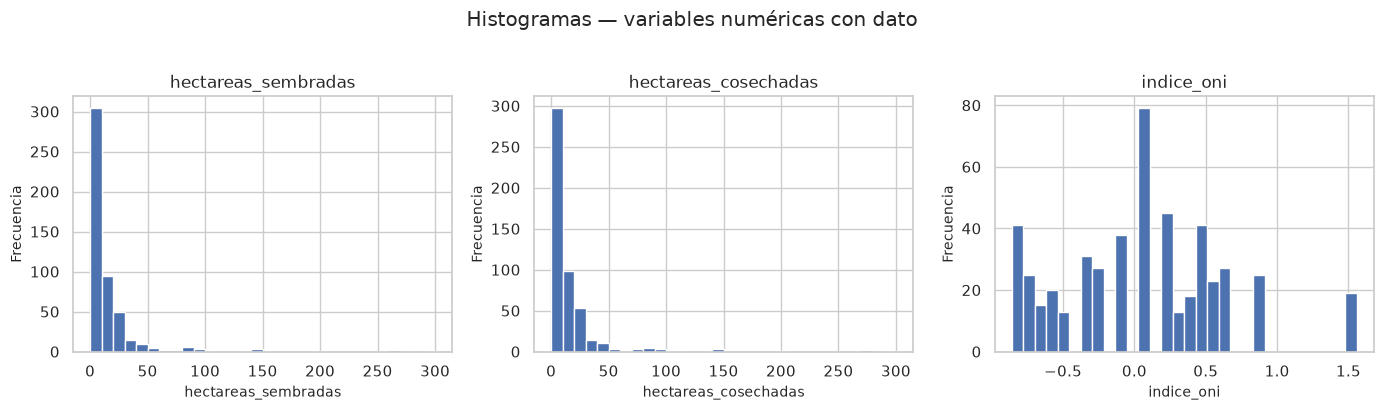

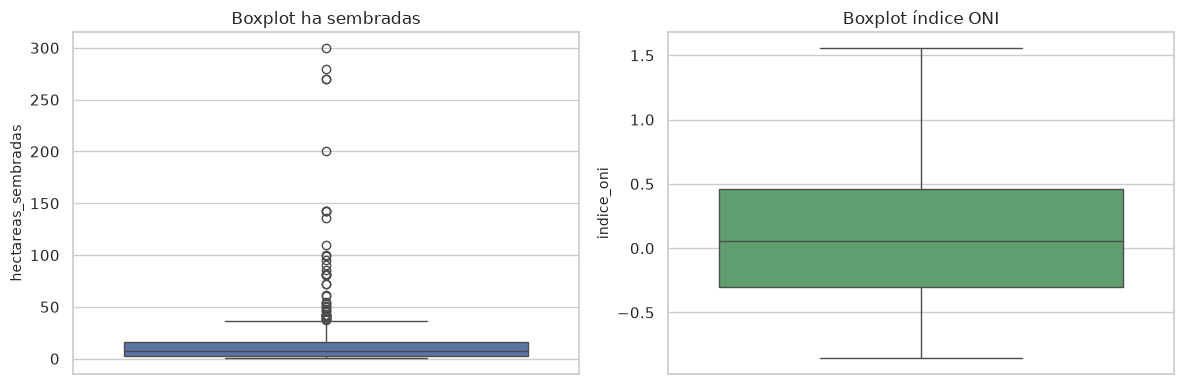

In [9]:
def dispersion(s: pd.Series) -> dict:
    s = s.dropna()
    if s.empty:
        return {}
    q1, q3 = s.quantile(0.25), s.quantile(0.75)
    mean = float(s.mean())
    std = float(s.std(ddof=1)) if len(s) > 1 else np.nan
    return {
        "n": int(len(s)),
        "mean": mean,
        "std": std,
        "cv": (std / mean) if mean and pd.notna(std) else np.nan,
        "min": float(s.min()),
        "p25": float(q1),
        "median": float(s.median()),
        "p75": float(q3),
        "iqr": float(q3 - q1),
        "max": float(s.max()),
        "skew": float(s.skew()) if len(s) > 2 else np.nan,
    }


vars_disp = ["hectareas_sembradas", "hectareas_cosechadas", "indice_oni"]
disp_global = pd.DataFrame({c: dispersion(df[c]) for c in vars_disp}).T
print("Dispersión global")
display(disp_global.round(3))

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, col in zip(axes, vars_disp):
    ax.hist(df[col].dropna(), bins=30, color="C0", edgecolor="white")
    ax.set_title(col)
    ax.set_xlabel(col)
    ax.set_ylabel("Frecuencia")
plt.suptitle("Histogramas — variables numéricas con dato", y=1.02)
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.boxplot(y=df["hectareas_sembradas"], ax=axes[0], color="C0")
axes[0].set_title("Boxplot ha sembradas")
sns.boxplot(y=df["indice_oni"], ax=axes[1], color="C2")
axes[1].set_title("Boxplot índice ONI")
plt.tight_layout()
plt.show()


Dispersión ha sembradas — 40 municipios


,n,mean,std,cv,min,p25,median,p75,iqr,max,skew,municipio,n_cultivos
2,3,3.567,5.154,1.445,0.20,0.600,1.000,5.250,4.650,9.5,1.685,argelia,3
19,5,4.500,6.285,1.397,1.00,1.000,1.000,4.000,3.000,15.5,2.018,jamundi,2
38,35,22.468,30.954,1.378,1.00,4.000,10.800,20.320,16.320,110.0,1.873,yumbo,5
33,14,3.307,3.989,1.206,1.50,1.850,2.250,2.875,1.025,17.0,3.588,trujillo,2
24,24,21.060,25.146,1.194,3.80,5.925,14.315,20.900,14.975,100.0,2.117,palmira,4
8,9,8.667,10.247,1.182,2.00,4.000,4.000,7.000,3.000,34.0,2.341,calima darien,1
11,7,2.779,3.242,1.167,0.55,1.450,2.000,2.000,0.550,10.0,2.444,el aguila,4
4,23,17.735,16.745,0.944,1.00,2.750,11.000,36.950,34.200,46.0,0.563,buga,5
0,3,24.533,23.094,0.941,11.20,11.200,11.200,31.200,20.000,51.2,1.732,alcala,1
17,22,6.341,5.717,0.902,1.00,3.000,4.000,8.000,5.000,25.2,2.068,guacari,2


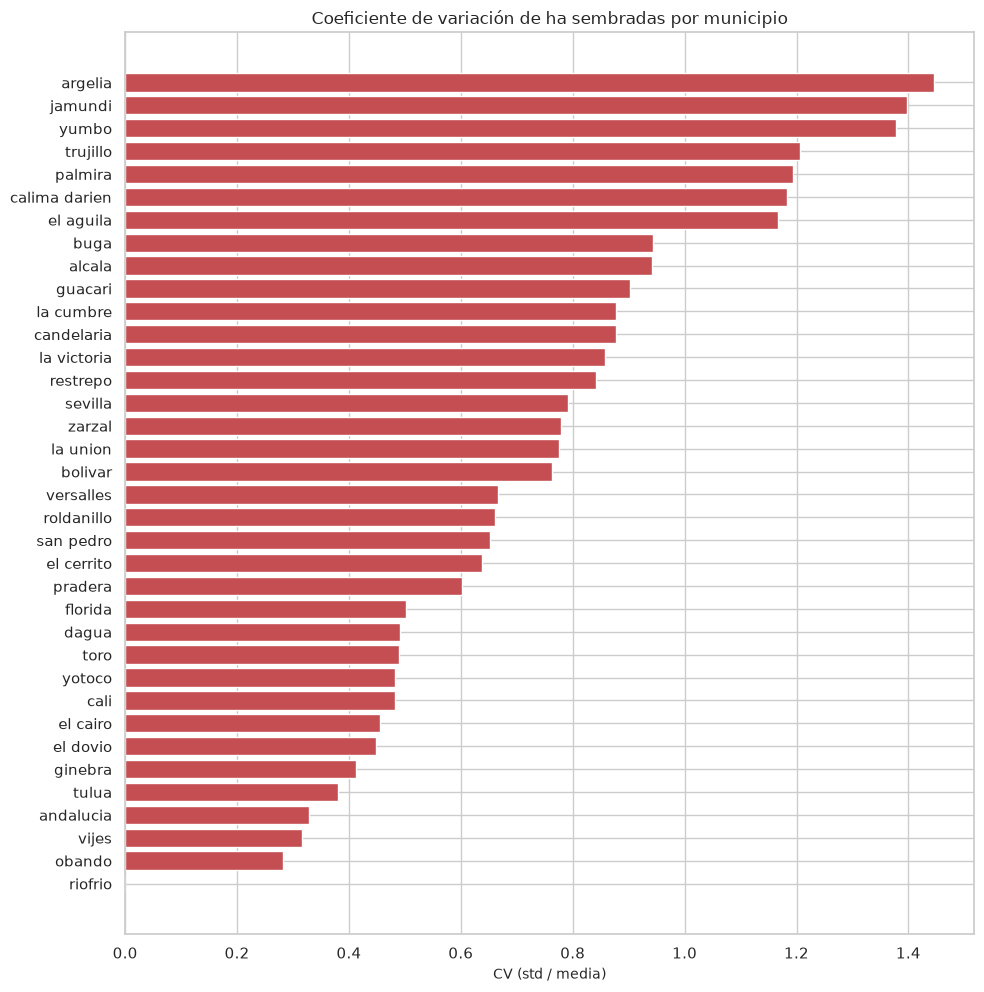

In [10]:
rows = []
for mun, g in df.groupby("municipio"):
    d = dispersion(g["hectareas_sembradas"])
    d["municipio"] = mun
    d["n_cultivos"] = g["nombre_cultivo"].nunique()
    rows.append(d)
disp_mun = pd.DataFrame(rows).sort_values("cv", ascending=False, na_position="last")
print(f"Dispersión ha sembradas — {len(disp_mun)} municipios")
display(disp_mun.round(3))

plot = disp_mun.dropna(subset=["cv"]).sort_values("cv")
fig, ax = plt.subplots(figsize=(10, max(6, len(plot) * 0.28)))
ax.barh(plot["municipio"], plot["cv"], color="C3")
ax.set_xlabel("CV (std / media)")
ax.set_title("Coeficiente de variación de ha sembradas por municipio")
plt.tight_layout()
plt.show()


Dispersión ha sembradas — 8 cultivos


,n,mean,std,cv,min,p25,median,p75,iqr,max,skew,nombre_cultivo,tipo,n_municipios
3,9,27.794,64.886,2.334,0.20,2.00,6.4,11.000,9.000,200.0,2.946,cebolla bulbo,transitorio,9
4,98,26.350,59.773,2.268,0.30,2.25,6.1,15.075,12.825,300.0,3.502,cebolla larga,permanente,20
5,49,4.688,7.232,1.543,1.00,2.00,3.0,4.800,2.800,51.2,5.794,flores y follajes,permanente,12
0,329,15.018,17.981,1.197,1.00,4.00,10.0,19.000,15.000,110.0,2.807,aji,permanente,33
1,4,3.100,2.812,0.907,0.40,1.60,2.5,4.000,2.400,7.0,1.149,anturios,permanente,4
7,9,15.964,14.121,0.885,1.05,5.50,14.5,23.000,17.500,45.8,1.156,plantas aromaticas,permanente,9
2,1,0.900,NaN,NaN,0.90,0.90,0.9,0.900,0.000,0.9,NaN,astromelias,permanente,1
6,1,10.000,NaN,NaN,10.00,10.00,10.0,10.000,0.000,10.0,NaN,heliconias,permanente,1


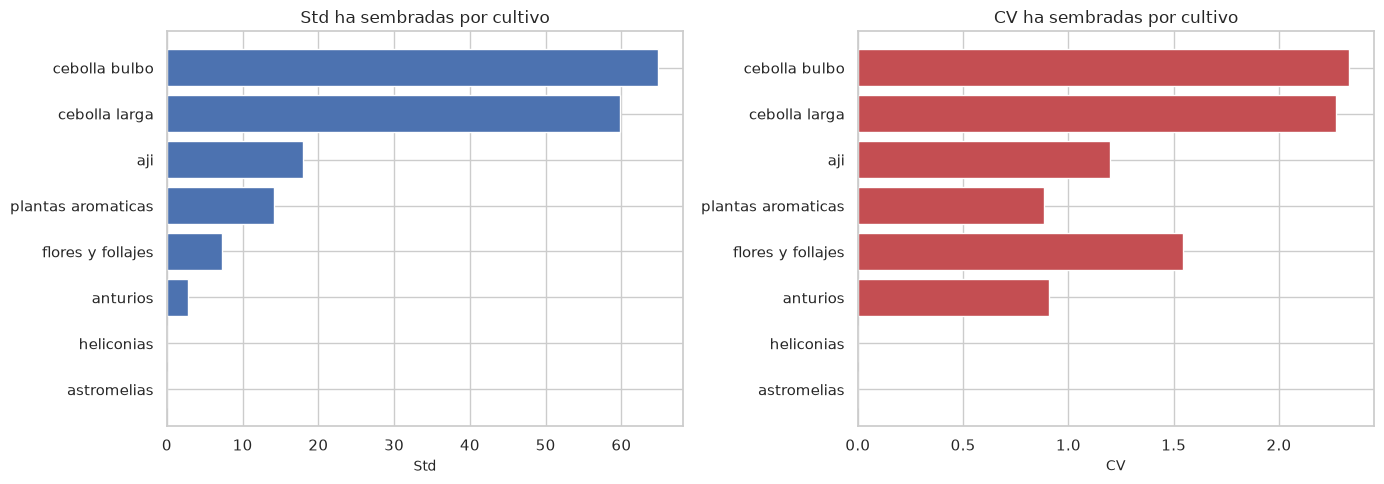

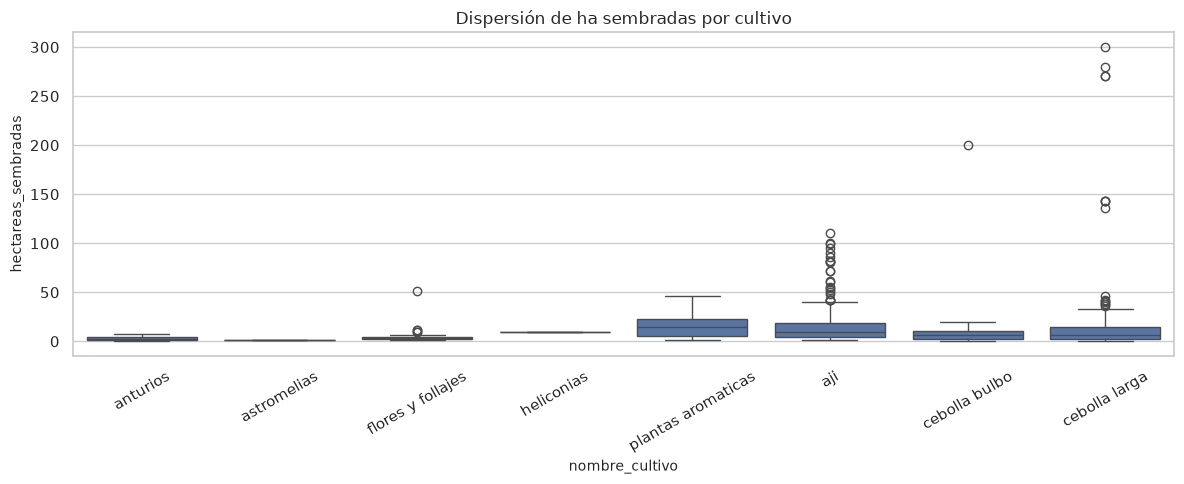

In [11]:
rows = []
for cul, g in df.groupby("nombre_cultivo"):
    d = dispersion(g["hectareas_sembradas"])
    d["nombre_cultivo"] = cul
    d["tipo"] = g["tipo_cultivo"].iloc[0]
    d["n_municipios"] = g["municipio"].nunique()
    rows.append(d)
disp_cul = pd.DataFrame(rows).sort_values("cv", ascending=False, na_position="last")
print(f"Dispersión ha sembradas — {len(disp_cul)} cultivos")
display(disp_cul.round(3))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
plot = disp_cul.sort_values("std", na_position="first")
axes[0].barh(plot["nombre_cultivo"], plot["std"].fillna(0), color="C0")
axes[0].set_xlabel("Std")
axes[0].set_title("Std ha sembradas por cultivo")
axes[1].barh(plot["nombre_cultivo"], plot["cv"].fillna(0), color="C3")
axes[1].set_xlabel("CV")
axes[1].set_title("CV ha sembradas por cultivo")
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(12, 5))
sns.boxplot(data=df, x="nombre_cultivo", y="hectareas_sembradas", ax=ax)
ax.tick_params(axis="x", rotation=30)
ax.set_title("Dispersión de ha sembradas por cultivo")
plt.tight_layout()
plt.show()


In [12]:
rows = []
for (mun, cul), g in df.groupby(["municipio", "nombre_cultivo"]):
    d = dispersion(g["hectareas_sembradas"])
    d["municipio"] = mun
    d["nombre_cultivo"] = cul
    rows.append(d)
disp_mc = (
    pd.DataFrame(rows)
    .sort_values(["std", "municipio"], ascending=[False, True], na_position="last")
    .reset_index(drop=True)
)
print(f"Dispersión ha sembradas — {len(disp_mc)} pares municipio × cultivo")
disp_mc.round(3)


Dispersión ha sembradas — 89 pares municipio × cultivo


,n,mean,std,cv,min,p25,median,p75,iqr,max,skew,municipio,nombre_cultivo
0,8,210.575,74.833,0.355,135.60,143.00,206.50,272.500,129.500,300.00,0.056,el cerrito,cebolla larga
1,23,30.286,34.800,1.149,2.00,10.27,13.00,23.600,13.330,110.00,1.432,yumbo,aji
2,15,39.349,30.520,0.776,12.00,16.50,22.90,65.565,49.065,95.00,0.861,la union,aji
3,11,37.191,29.277,0.787,19.00,20.70,20.90,47.500,26.800,100.00,1.438,palmira,aji
4,3,24.533,23.094,0.941,11.20,11.20,11.20,31.200,20.000,51.20,1.732,alcala,flores y follajes
...,...,...,...,...,...,...,...,...,...,...,...,...,...
84,1,1.050,NaN,NaN,1.05,1.05,1.05,1.050,0.000,1.05,NaN,sevilla,plantas aromaticas
85,1,8.000,NaN,NaN,8.00,8.00,8.00,8.000,0.000,8.00,NaN,tulua,cebolla bulbo
86,1,0.400,NaN,NaN,0.40,0.40,0.40,0.400,0.000,0.40,NaN,versalles,anturios
87,1,6.400,NaN,NaN,6.40,6.40,6.40,6.400,0.000,6.40,NaN,yumbo,cebolla bulbo


## 5. Análisis de correlación

Matrices Pearson y Spearman a nivel fila; relación ha↔ONI por quintiles y a nivel anual; correlaciones por cultivo y por municipio (`n ≥ 5`).


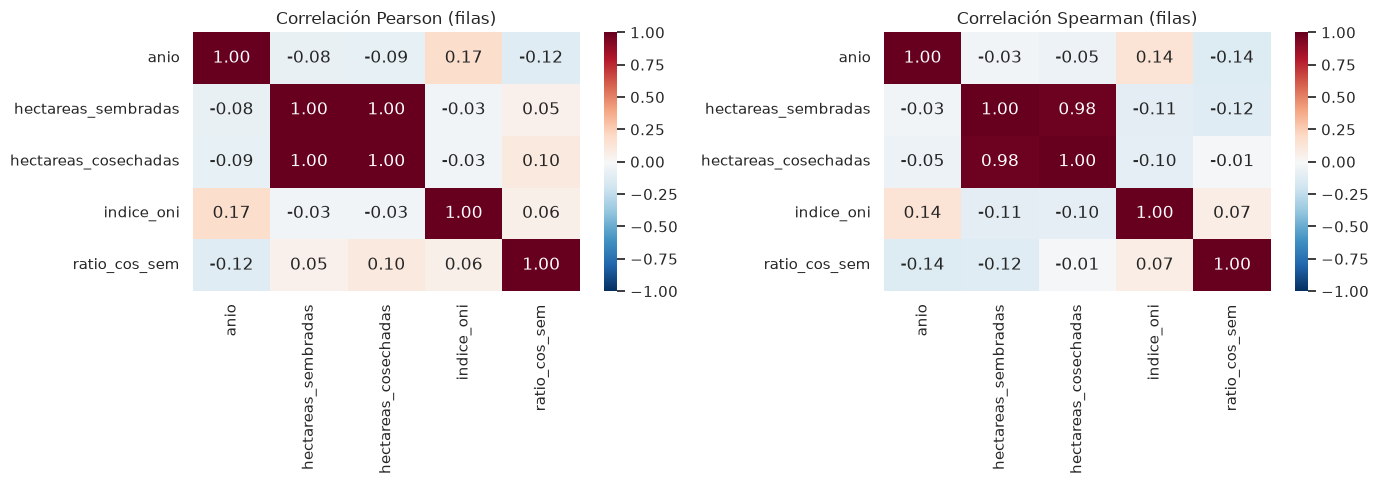

,anio,hectareas_sembradas,hectareas_cosechadas,indice_oni,ratio_cos_sem
anio,1.000,-0.077,-0.085,0.174,-0.118
hectareas_sembradas,-0.077,1.000,0.996,-0.034,0.047
hectareas_cosechadas,-0.085,0.996,1.000,-0.032,0.099
indice_oni,0.174,-0.034,-0.032,1.000,0.056
ratio_cos_sem,-0.118,0.047,0.099,0.056,1.000


,anio,hectareas_sembradas,hectareas_cosechadas,indice_oni,ratio_cos_sem
anio,1.000,-0.034,-0.055,0.138,-0.140
hectareas_sembradas,-0.034,1.000,0.981,-0.107,-0.120
hectareas_cosechadas,-0.055,0.981,1.000,-0.098,-0.009
indice_oni,0.138,-0.107,-0.098,1.000,0.073
ratio_cos_sem,-0.140,-0.120,-0.009,0.073,1.000


In [13]:
corr_cols = [
    "anio",
    "hectareas_sembradas",
    "hectareas_cosechadas",
    "indice_oni",
    "ratio_cos_sem",
]

pearson = df[corr_cols].corr(method="pearson")
spearman = df[corr_cols].corr(method="spearman")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.heatmap(pearson, annot=True, fmt=".2f", cmap="RdBu_r", center=0, ax=axes[0], vmin=-1, vmax=1)
axes[0].set_title("Correlación Pearson (filas)")
sns.heatmap(spearman, annot=True, fmt=".2f", cmap="RdBu_r", center=0, ax=axes[1], vmin=-1, vmax=1)
axes[1].set_title("Correlación Spearman (filas)")
plt.tight_layout()
plt.show()

display(pearson.round(3))
display(spearman.round(3))


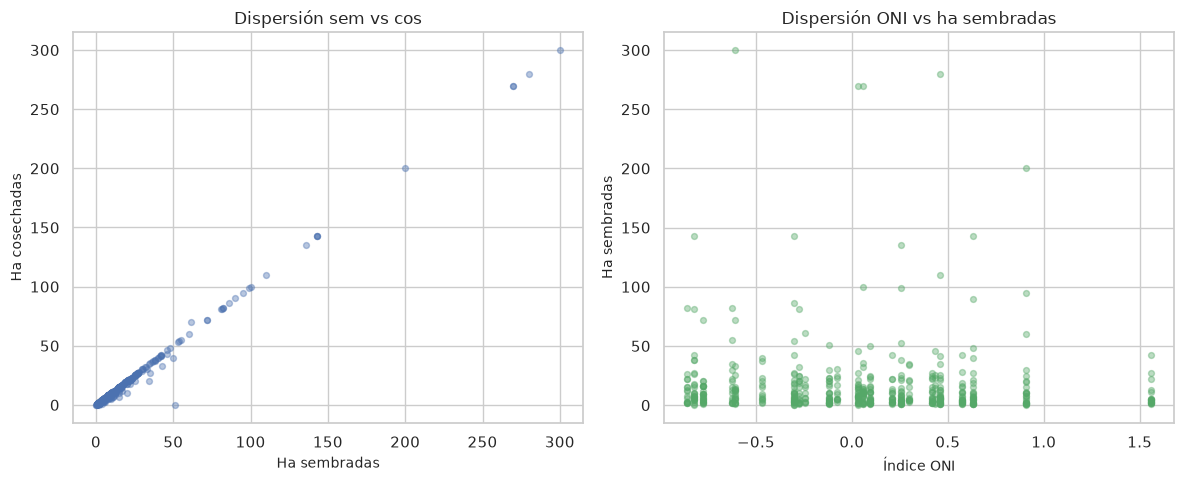

,oni_q,n,ha_mean,ha_median,oni_mean
0,"(-0.859, -0.608]",101,18.968,9.0,-0.745
1,"(-0.608, -0.075]",109,14.592,8.0,-0.243
2,"(-0.075, 0.208]",97,16.366,8.0,0.088
3,"(0.208, 0.458]",99,16.877,6.2,0.373
4,"(0.458, 1.558]",94,14.951,5.0,0.879


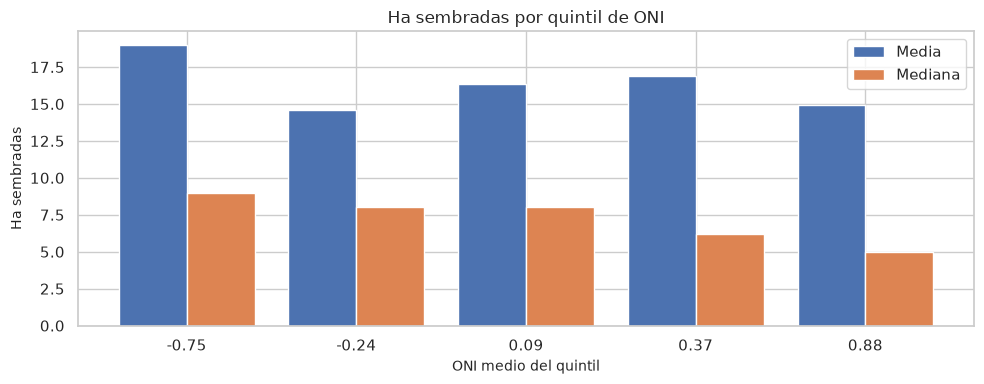

Pearson anual (suma ha vs ONI): 0.0446
Spearman anual (suma ha vs ONI): 0.0362


In [14]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].scatter(df["hectareas_sembradas"], df["hectareas_cosechadas"], alpha=0.4, s=18)
axes[0].set_xlabel("Ha sembradas")
axes[0].set_ylabel("Ha cosechadas")
axes[0].set_title("Dispersión sem vs cos")

axes[1].scatter(df["indice_oni"], df["hectareas_sembradas"], alpha=0.4, s=18, color="C2")
axes[1].set_xlabel("Índice ONI")
axes[1].set_ylabel("Ha sembradas")
axes[1].set_title("Dispersión ONI vs ha sembradas")
plt.tight_layout()
plt.show()

tmp = df.copy()
tmp["oni_q"] = pd.qcut(tmp["indice_oni"], q=5, duplicates="drop")
oni_bins = (
    tmp.groupby("oni_q", observed=True)
    .agg(
        n=("hectareas_sembradas", "count"),
        ha_mean=("hectareas_sembradas", "mean"),
        ha_median=("hectareas_sembradas", "median"),
        oni_mean=("indice_oni", "mean"),
    )
    .reset_index()
)
display(oni_bins.round(3))

fig, ax = plt.subplots(figsize=(10, 4))
x = np.arange(len(oni_bins))
ax.bar(x - 0.2, oni_bins["ha_mean"], width=0.4, label="Media")
ax.bar(x + 0.2, oni_bins["ha_median"], width=0.4, label="Mediana")
ax.set_xticks(x)
ax.set_xticklabels([f"{v:.2f}" for v in oni_bins["oni_mean"]])
ax.set_xlabel("ONI medio del quintil")
ax.set_ylabel("Ha sembradas")
ax.set_title("Ha sembradas por quintil de ONI")
ax.legend()
plt.tight_layout()
plt.show()

r_year_p = by_year["ha_sem"].corr(by_year["oni"], method="pearson")
r_year_s = by_year["ha_sem"].corr(by_year["oni"], method="spearman")
print(f"Pearson anual (suma ha vs ONI): {r_year_p:.4f}")
print(f"Spearman anual (suma ha vs ONI): {r_year_s:.4f}")


In [15]:
crop_corr = []
for cul, g in df.groupby("nombre_cultivo"):
    row = {"nombre_cultivo": cul, "n": len(g)}
    if len(g) >= 5:
        row["pearson_ha_oni"] = g["hectareas_sembradas"].corr(g["indice_oni"])
        row["spearman_ha_oni"] = g["hectareas_sembradas"].corr(g["indice_oni"], method="spearman")
        row["pearson_ha_anio"] = g["hectareas_sembradas"].corr(g["anio"])
        row["spearman_ha_anio"] = g["hectareas_sembradas"].corr(g["anio"], method="spearman")
        row["pearson_sem_cos"] = g["hectareas_sembradas"].corr(g["hectareas_cosechadas"])
    else:
        row.update(
            {
                "pearson_ha_oni": np.nan,
                "spearman_ha_oni": np.nan,
                "pearson_ha_anio": np.nan,
                "spearman_ha_anio": np.nan,
                "pearson_sem_cos": np.nan,
            }
        )
    crop_corr.append(row)

crop_corr_df = pd.DataFrame(crop_corr).sort_values("n", ascending=False)
print("Correlación por cultivo")
display(crop_corr_df.round(3))

mun_corr = []
for mun, g in df.groupby("municipio"):
    if len(g) < 5:
        continue
    mun_corr.append(
        {
            "municipio": mun,
            "n": len(g),
            "pearson_ha_oni": g["hectareas_sembradas"].corr(g["indice_oni"]),
            "pearson_ha_anio": g["hectareas_sembradas"].corr(g["anio"]),
            "pearson_sem_cos": g["hectareas_sembradas"].corr(g["hectareas_cosechadas"]),
            "cv_ha": (
                g["hectareas_sembradas"].std() / g["hectareas_sembradas"].mean()
                if g["hectareas_sembradas"].mean()
                else np.nan
            ),
        }
    )
mun_corr_df = (
    pd.DataFrame(mun_corr)
    .assign(abs_r=lambda x: x["pearson_ha_oni"].abs())
    .sort_values("abs_r", ascending=False)
    .drop(columns="abs_r")
)
print("\nCorrelación por municipio (n ≥ 5), ordenado por |Pearson ha↔ONI|")
display(mun_corr_df.round(3))


Correlación por cultivo


/home/jjvallej/work/enigma/pyimport/.venv/lib/python3.14/site-packages/numpy/lib/_function_base_impl.py:3036: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/home/jjvallej/work/enigma/pyimport/.venv/lib/python3.14/site-packages/numpy/lib/_function_base_impl.py:3037: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]
/home/jjvallej/work/enigma/pyimport/.venv/lib/python3.14/site-packages/pandas/core/nanops.py:1673: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  return spearmanr(a, b)[0]


,nombre_cultivo,n,pearson_ha_oni,spearman_ha_oni,pearson_ha_anio,spearman_ha_anio,pearson_sem_cos
0,aji,329,-0.021,-0.036,-0.037,-0.021,0.996
4,cebolla larga,98,-0.036,-0.142,0.130,-0.060,1.000
5,flores y follajes,49,-0.145,0.016,0.032,-0.154,0.148
3,cebolla bulbo,9,NaN,NaN,NaN,NaN,0.999
7,plantas aromaticas,9,NaN,NaN,NaN,NaN,0.998
1,anturios,4,NaN,NaN,NaN,NaN,NaN
2,astromelias,1,NaN,NaN,NaN,NaN,NaN
6,heliconias,1,NaN,NaN,NaN,NaN,NaN



Correlación por municipio (n ≥ 5), ordenado por |Pearson ha↔ONI|


,municipio,n,pearson_ha_oni,pearson_ha_anio,pearson_sem_cos,cv_ha
10,ginebra,8,-0.749,-0.483,1.000,0.412
21,sevilla,8,-0.711,-0.295,1.000,0.792
15,la victoria,8,0.569,0.357,0.927,0.858
6,el aguila,7,-0.491,-0.450,1.000,1.167
27,yotoco,9,-0.463,0.873,0.986,0.483
9,florida,11,-0.411,-0.942,1.000,0.502
16,palmira,24,-0.371,-0.171,1.000,1.194
17,pradera,14,0.352,-0.738,0.957,0.601
12,jamundi,5,-0.311,0.024,1.000,1.397
8,el dovio,9,-0.311,0.467,0.790,0.449


## 6. Hallazgos principales

- El extracto cubre **todos** los municipios y cultivos presentes en el CSV (matriz municipio×cultivo dispersa).
- **Ají** concentra la mayor parte del área sembrada; **cebolla larga** es relevante pero con ventana temporal corta (hasta ~2007).
- `precio` y `semestre` pueden estar **100% nulos** en este archivo: no aportan señal aquí.
- Alta **dispersión** de hectáreas (CV alto, sesgo positivo fuerte: media ≫ mediana).
- **Correlación** siembra↔cosecha ≈ 1; ha↔ONI ≈ 0 a nivel global y anual. Correlaciones locales altas en algunos municipios suelen basarse en pocas filas — no inferir causalidad.
- Revisar posibles duplicados de nombre (`buga` / `guadalajara de buga`, `cali` / `santiago de cali`).
